IT Incident Ticket Analysis

Identifying Drivers of Resolution Time in Enterprise IT Operations


0. Objective & Motivation

Objective:
The goal of this analysis is to examine IT incident ticket data to identify factors that contribute to longer resolution times and operational bottlenecks. Understanding these drivers can inform process improvements, resource allocation, and SLA management.

Why this matters:
In enterprise IT environments, prolonged incident resolution impacts employee productivity and operational reliability. Data-driven insights can help prioritize improvements and reduce mean time to resolution (MTTR).


In [1]:
#import necessary packages and load data

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv(r'C:\Users\Vishnu Ravi\python files\IT ticket data analysis project\incident_event_log.csv')
print(df.shape)
pd.set_option('display.max_columns', None)

(119998, 36)


Data Understanding

In [2]:
df.head()


,number,incident_state,active,reassignment_count,reopen_count,sys_mod_count,made_sla,caller_id,opened_by,opened_at,sys_created_by,sys_created_at,sys_updated_by,sys_updated_at,contact_type,location,category,subcategory,u_symptom,cmdb_ci,impact,urgency,priority,assignment_group,assigned_to,knowledge,u_priority_confirmation,notify,problem_id,rfc,vendor,caused_by,closed_code,resolved_by,resolved_at,closed_at
0,INC0000045,New,True,0,0,0,True,Caller 2403,Opened by 8,29/2/2016 01:16,Created by 6,29/2/2016 01:23,Updated by 21,29/2/2016 01:23,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,?,2 - Medium,2 - Medium,3 - Moderate,Group 56,?,True,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
1,INC0000045,Resolved,True,0,0,2,True,Caller 2403,Opened by 8,29/2/2016 01:16,Created by 6,29/2/2016 01:23,Updated by 642,29/2/2016 08:53,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,?,2 - Medium,2 - Medium,3 - Moderate,Group 56,?,True,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
2,INC0000045,Resolved,True,0,0,3,True,Caller 2403,Opened by 8,29/2/2016 01:16,Created by 6,29/2/2016 01:23,Updated by 804,29/2/2016 11:29,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,?,2 - Medium,2 - Medium,3 - Moderate,Group 56,?,True,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
3,INC0000045,Closed,False,0,0,4,True,Caller 2403,Opened by 8,29/2/2016 01:16,Created by 6,29/2/2016 01:23,Updated by 908,5/3/2016 12:00,Phone,Location 143,Category 55,Subcategory 170,Symptom 72,?,2 - Medium,2 - Medium,3 - Moderate,Group 56,?,True,False,Do Not Notify,?,?,?,?,code 5,Resolved by 149,29/2/2016 11:29,5/3/2016 12:00
4,INC0000047,New,True,0,0,0,True,Caller 2403,Opened by 397,29/2/2016 04:40,Created by 171,29/2/2016 04:57,Updated by 746,29/2/2016 04:57,Phone,Location 165,Category 40,Subcategory 215,Symptom 471,?,2 - Medium,2 - Medium,3 - Moderate,Group 70,Resolver 89,True,False,Do Not Notify,?,?,?,?,code 5,Resolved by 81,1/3/2016 09:52,6/3/2016 10:00


As seen above, this dataset is event-level, and each row represents an event rather than an incident. Each number contains multiple rows with the following columns being updated over the course of rows [incident_state, sys_mod_count,sys_updated_by]. 
Additionally, it seems that resolved_at is being backfilled, as even while incidents are new they have a resolved_at value that is the same as when the incident is closed. This also goes for every other time based column.

In [3]:
print(f"Number of missing values = {(df == '?').sum()}") 

Number of missing values = number                          0
incident_state                  0
active                          0
reassignment_count              0
reopen_count                    0
sys_mod_count                   0
made_sla                        0
caller_id                      29
opened_by                    4835
opened_at                       0
sys_created_by              42354
sys_created_at              42354
sys_updated_by                  0
sys_updated_at                  0
contact_type                    0
location                       76
category                       64
subcategory                    97
u_symptom                   28271
cmdb_ci                    119562
impact                          0
urgency                         0
priority                        0
assignment_group            14213
assigned_to                 23030
knowledge                       0
u_priority_confirmation         0
notify                          0
problem_id           

The following columns show high rates of missing data(>90%) ['problem_id','rfc','vendor','caused_by','cmdb_ci'], as a result, we will drop them. 



In [4]:
print(df.index[df["resolved_at"] == "?"])
df.drop(columns =['problem_id','rfc','vendor','caused_by','cmdb_ci'])
print(df.iloc[173:175])

Index([   173,    174,    423,    424,    548,    549,    742,    743,    814,
          815,
       ...
       119262, 119263, 119353, 119354, 119398, 119399, 119633, 119634, 119995,
       119996],
      dtype='int64', length=2861)
         number incident_state  active  reassignment_count  reopen_count  \
173  INC0000093       Resolved    True                   0             0   
174  INC0000093         Closed   False                   0             0   

     sys_mod_count  made_sla    caller_id       opened_by        opened_at  \
173              0      True  Caller 3545  Opened by  131  29/2/2016 08:56   
174              1      True  Caller 3545  Opened by  131  29/2/2016 08:56   

    sys_created_by sys_created_at  sys_updated_by   sys_updated_at  \
173              ?              ?  Updated by 908  29/2/2016 08:56   
174              ?              ?  Updated by 908   5/3/2016 10:00   

    contact_type     location     category      subcategory    u_symptom  \
173        Phon

Judging by the above, missing values for resolved_at are not found in later entries, which is consistent with how entries for resolved_at are backfilled even if the incident is open in the row. 


In [5]:
#checking what percentage of incidents fail to make sla

print("Number of incidents with SLA made:",len(df[df.made_sla==False]['number'].unique())/len(df.number.unique()))

Number of incidents with SLA made: 0.39356733593336224


SLA(Service Level Agreement) is an agreement made between a service provider and a customer about the standards of the service being provided, and includes things like performance metrics and responsibilities of the provider.

Having nearly 40% of incidents miss SLA would be a horrible scenario for any IT service provider



In [ ]:
#To see how there's such a high number of missed SLAs, we'll look at the tickets that missed their SLA

missed_sla = df[df.made_sla==False]


missed_sla.head()

,number,incident_state,active,reassignment_count,reopen_count,sys_mod_count,made_sla,caller_id,opened_by,opened_at,sys_created_by,sys_created_at,sys_updated_by,sys_updated_at,contact_type,location,category,subcategory,u_symptom,cmdb_ci,impact,urgency,priority,assignment_group,assigned_to,knowledge,u_priority_confirmation,notify,problem_id,rfc,vendor,caused_by,closed_code,resolved_by,resolved_at,closed_at
31,INC0000062,Closed,False,1,0,7,False,Caller 3765,Opened by 180,29/2/2016 06:58,Created by 81,29/2/2016 07:26,Updated by 908,5/3/2016 16:00,Phone,Location 93,Category 53,Subcategory 168,Symptom 232,?,1 - High,2 - Medium,2 - High,Group 23,?,True,False,Do Not Notify,?,?,?,?,code 7,Resolved by 62,29/2/2016 15:51,5/3/2016 16:00
84,INC0000070,Closed,False,1,0,9,False,Caller 3757,Opened by 131,29/2/2016 08:11,Created by 62,29/2/2016 08:38,Updated by 908,24/3/2016 18:40,Phone,Location 46,Category 9,Subcategory 164,Symptom 592,?,2 - Medium,2 - Medium,3 - Moderate,Group 29,Resolver 31,True,False,Do Not Notify,?,?,?,?,code 11,Resolved by 30,8/3/2016 09:55,24/3/2016 18:40
104,INC0000074,Closed,False,0,0,19,False,Caller 527,Opened by 433,29/2/2016 08:23,?,?,Updated by 908,16/4/2016 15:07,Phone,Location 204,Category 45,Subcategory 220,?,?,2 - Medium,2 - Medium,3 - Moderate,Group 66,Resolver 193,True,True,Do Not Notify,?,CHG0000404,?,?,code 6,Resolved by 158,11/4/2016 14:39,16/4/2016 15:07
137,INC0000084,Closed,False,0,0,19,False,Caller 3038,Opened by 433,29/2/2016 08:39,?,?,Updated by 908,17/4/2016 15:07,Phone,Location 204,Category 45,Subcategory 220,Symptom 253,?,3 - Low,3 - Low,4 - Low,Group 66,Resolver 175,True,True,Do Not Notify,?,CHG0000647,?,?,code 6,Resolved by 158,12/4/2016 14:46,17/4/2016 15:07
172,INC0000092,Closed,False,1,0,6,False,Caller 1811,Opened by 40,29/2/2016 08:55,?,?,Updated by 908,12/3/2016 09:00,Phone,Location 172,Category 53,Subcategory 271,Symptom 470,?,2 - Medium,2 - Medium,3 - Moderate,Group 72,?,True,False,Do Not Notify,Problem ID 2,?,?,?,code 5,Resolved by 99,7/3/2016 08:45,12/3/2016 09:00


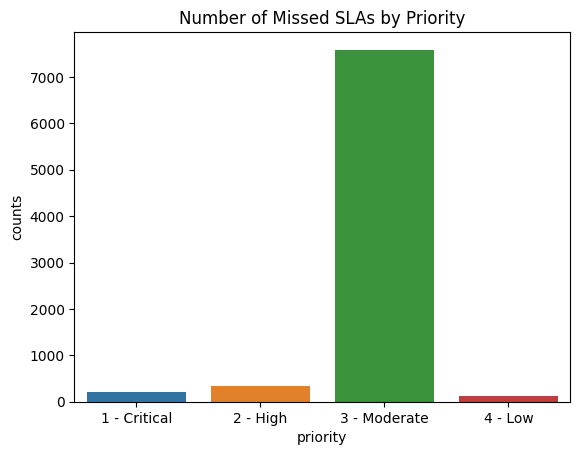

In [7]:
#we'll graph the number of missed SLAs by priority to see if there's a trend
missed_sla_priority = missed_sla.groupby('priority').size().reset_index(name='counts')
sns.barplot(x='priority', y='counts', data=missed_sla_priority)
plt.title('Number of Missed SLAs by Priority')
plt.show()


       priority  counts
0  1 - Critical     215
1      2 - High     336
2  3 - Moderate    7588
3       4 - Low     121


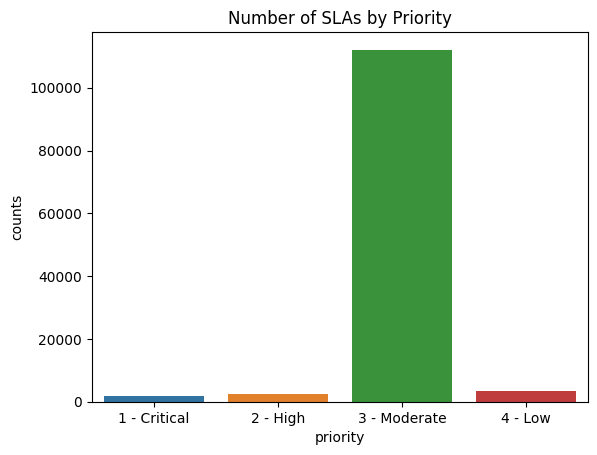

In [ ]:
#print(regular_sla_priority)
print(missed_sla_priority)
regular_sla_priority = df.groupby('priority').size().reset_index(name='counts')
sns.barplot(x='priority', y='counts', data=regular_sla_priority)
plt.title('Number of SLAs by Priority')
plt.show()

In [10]:
import pandas as pd
from scipy.stats import chi2_contingency

# Ensure the dataframes are aligned by priority
merged = pd.merge(
    regular_sla_priority[['priority', 'counts']],
    missed_sla_priority[['priority', 'counts']],
    on='priority',
    how='inner',
    suffixes=('_regular', '_missed')
)

# Build contingency table
contingency_table = merged[['counts_regular', 'counts_missed']].T.values

# Chi-squared test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-squared statistic:", chi2)
print("Degrees of freedom:", dof)
print("p-value:", p_value)

# Optional: expected frequencies
expected_df = pd.DataFrame(
    expected,
    columns=merged['priority'],
    index=['Regular SLA', 'Missed SLA']
)
print("\nExpected frequencies:")
print(expected_df)
import numpy as np

n = contingency_table.sum()
cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))
print("Cramér’s V:", cramers_v)


Chi-squared statistic: 255.74272523412614
Degrees of freedom: 3
p-value: 3.747165264732421e-55

Expected frequencies:
priority     1 - Critical     2 - High   3 - Moderate      4 - Low
Regular SLA   1917.977046  2652.421915  111993.954326  3433.646712
Missed SLA     132.022954   182.578085    7709.045674   236.353288
Cramér’s V: 0.04465390176915344


Priority is clearly related to whether an SLA is missed (χ² = 255.7, p < 0.001). Missed SLAs are more common than expected for Critical and High priority tickets, and less common for Low priority ones.


That said, the effect size is small (Cramér’s V = 0.045), so priority alone isn’t a strong predictor. It matters, but other factors likely play a bigger role in whether an SLA gets missed.

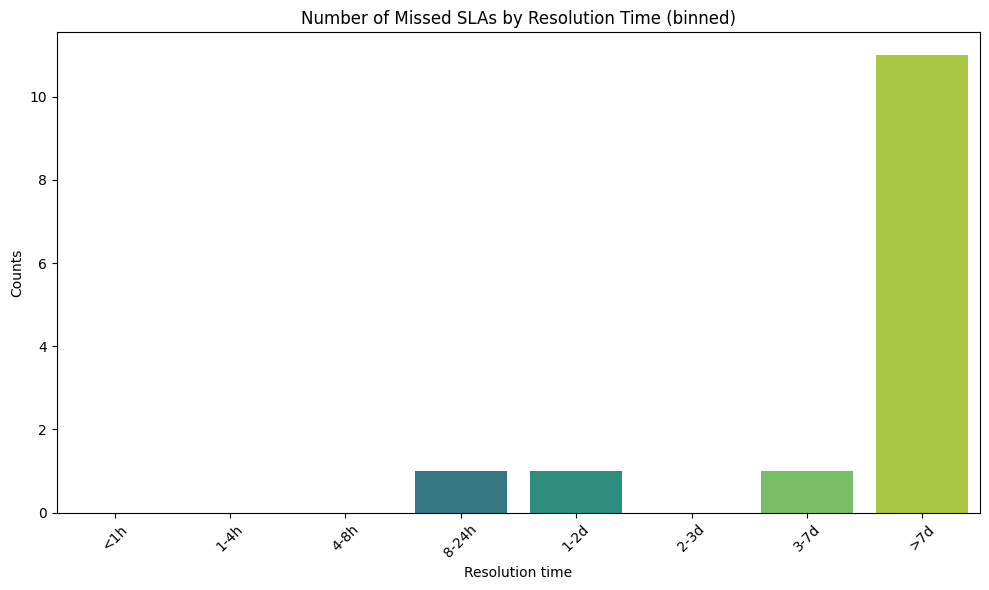

In [12]:
# Take a sample and compute resolution time in hours
df_500 = df.iloc[:500].copy()
# Parse datetime columns; coerce invalid placeholders (like '?') to NaT
df_500['opened_at_dt'] = pd.to_datetime(df_500['opened_at'], errors='coerce', dayfirst=True)
df_500['resolved_at_dt'] = pd.to_datetime(df_500['resolved_at'], errors='coerce', dayfirst=True)
# Compute difference in hours (will be NaN where parsing failed)
df_500['difference'] = (df_500['resolved_at_dt'] - df_500['opened_at_dt']).dt.total_seconds() / 3600.0
# Filter missed SLAs and drop rows with missing differences
missed_sla = df_500[df_500.made_sla==False].copy()
missed_sla = missed_sla[missed_sla['difference'].notna()].copy()

# Bin the continuous time-difference into readable intervals
import numpy as np
bins = [0, 1, 4, 8, 24, 48, 72, 168, np.inf]
labels = ['<1h', '1-4h', '4-8h', '8-24h', '1-2d', '2-3d', '3-7d', '>7d']
missed_sla['diff_bin'] = pd.cut(missed_sla['difference'], bins=bins, labels=labels, right=False)

missed_sla_time_difference = missed_sla.groupby('diff_bin').size().reset_index(name='counts')

plt.figure(figsize=(10, 6))
sns.barplot(x='diff_bin', y='counts', data=missed_sla_time_difference, order=labels, palette='viridis')
plt.title('Number of Missed SLAs by Resolution Time (binned)')
plt.xlabel('Resolution time')
plt.ylabel('Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# Compute and plot resolution times for regular (made) SLAs using same bins
# Use df_500 and previously computed 'difference' column
regular_sla = df_500[df_500.made_sla==True].copy()
regular_sla = regular_sla[regular_sla['difference'].notna()].copy()

import numpy as np
bins = [0, 1, 4, 8, 24, 48, 72, 168, np.inf]
labels = ['<1h', '1-4h', '4-8h', '8-24h', '1-2d', '2-3d', '3-7d', '>7d']
regular_sla['diff_bin'] = pd.cut(regular_sla['difference'], bins=bins, labels=labels, right=False)

regular_sla_time_difference = regular_sla.groupby('diff_bin').size().reset_index(name='counts')

plt.figure(figsize=(10, 6))
sns.barplot(x='diff_bin', y='counts', data=regular_sla_time_difference, order=labels, palette='magma')
plt.title('Number of Successful SLAs by Resolution Time (binned)')
plt.xlabel('Resolution time')
plt.ylabel('Counts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
regular_sla_priority = df.groupby('priority').size().reset_index(name='counts')

TO BE DONE LATER: STATISTICAL ANALYSIS ON THIS TO SEE WHETHER THERE'S A STATISTICALLY SIGNIFICANT DIFFERENCE BETWEEN THE TWO SETS 
CHECKING WHAT OTHER COLUMNS HAVE AN IMPACT ON MADE_SLA WITH GRAPHS AND STUFF(begin with time it takes for an incident to resolved by taking the difference of opened_at and closed_at) 

TO BE DONE LATER: LOOK THORUGH CODE TO UNDERSTAND IT, LEARN EACH PANDAS METHOD DONE IN EACH LINE OF CODE, IN ADDITION TO SEABORN STUFF(stats stuff is ignorable since it's taught in cmda) THEN FINISH OFF THIS BY DOING XGBOOST ON missed_sla with all of the dependent variables

AFTERWARDS: MOVE ONTO SQL PROJECT, step 1 is finding an SQL course and doing that then asking gpt for a project idea and doing that



In [13]:
plt.figure(figsize=(12, 6))

sns.histplot(
    df['difference'],
    bins=30,
    color='blue',
    label='Normal',
    stat='density',
    alpha=0.5
)

sns.histplot(
    missed_sla['difference'],
    bins=30,
    color='red',
    label='Missed SLA',
    stat='density',
    alpha=0.5
)

plt.xlabel('Time Difference (hours)')
plt.title('Distribution of Time Differences: Normal vs Missed SLA')
plt.legend()
plt.show()


KeyError: 'difference'

<Figure size 1200x600 with 0 Axes>

As evident from this graph, increased time difference is a large factor in missed_sla, although there are clearly other factors as even for low time difference between resolved_at and opened_at there are many missed_sla values. I suspect this has to due with the descriptive columns that are redacted for privacy as they contain descriptive information about the nature of the incident that is not captured by the other columns. 

It seems there are multiple teams working on this in different timezones, with the primary team working during normal working hours, with there likely being smaller teams set up in different timezones.